
Generating literature-informed response ensemble...
Response ensemble generation complete.


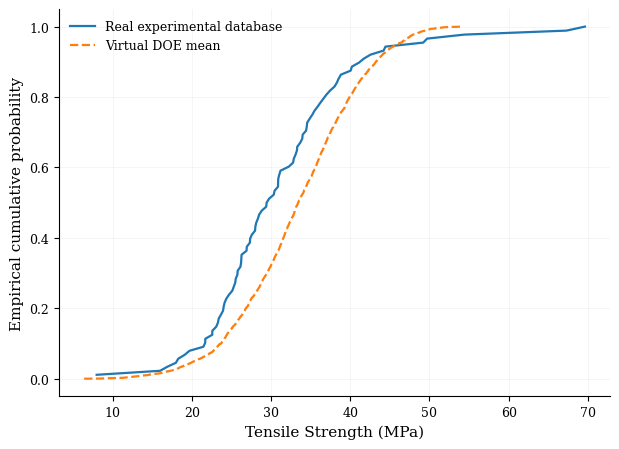

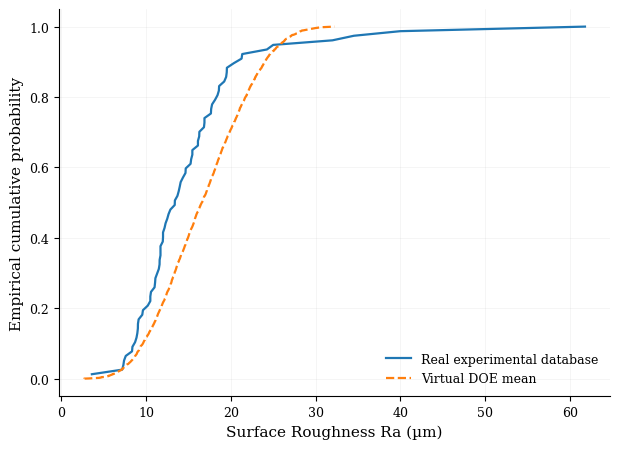

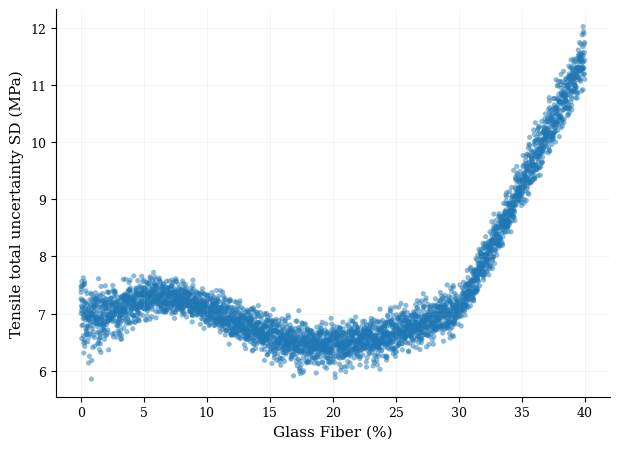

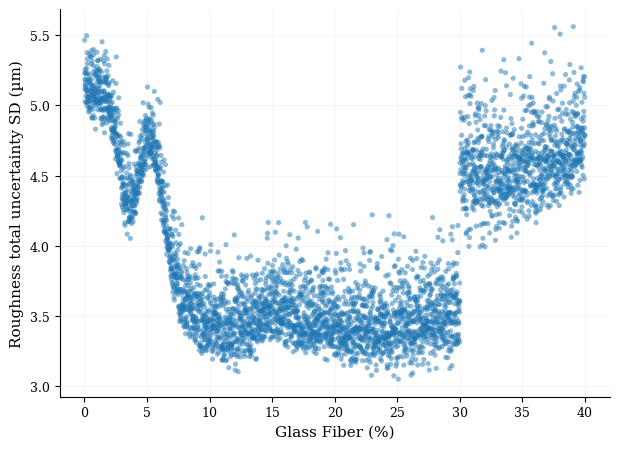


DISTRIBUTIONAL CALIBRATION


,Response,Real_N,Virtual_N,Real_Min,Virtual_Min,Real_Q05,Virtual_Q05,Real_Median,Virtual_Median,Real_Q95,Virtual_Q95,Real_Max,Virtual_Max,KS_Statistic,Wasserstein_Distance
0,Tensile Strength,88,4000,8.000000,6.426840,18.577400,20.335390,29.606500,33.424690,47.550500,45.966360,69.630000,54.093780,0.211160,3.398370
1,Surface Roughness,77,4000,3.600000,2.694920,7.560000,8.224570,13.400000,16.568810,26.400000,25.892500,61.800000,32.248410,0.222010,3.114990



VIRTUAL RESPONSE EFFECT DIRECTIONS


,Response,Variable,Parameter,Spearman_rho,p_value
0,Virtual Tensile,GF_pct,Glass Fiber (%),0.087890,0.000000
1,Virtual Tensile,Infill_pct,Infill Density (%),0.656670,0.000000
2,Virtual Tensile,Layer_mm,Layer Thickness (mm),-0.247430,0.000000
3,Virtual Tensile,Nozzle_C,Nozzle Temperature (°C),0.003780,0.811310
4,Virtual Tensile,Bed_C,Bed Temperature (°C),0.269500,0.000000
5,Virtual Tensile,Speed_mm_s,Printing Speed (mm/s),0.016660,0.292190
6,Virtual Roughness,GF_pct,Glass Fiber (%),-0.057830,0.000250
7,Virtual Roughness,Infill_pct,Infill Density (%),-0.164980,0.000000
8,Virtual Roughness,Layer_mm,Layer Thickness (mm),0.847100,0.000000
9,Virtual Roughness,Nozzle_C,Nozzle Temperature (°C),0.001180,0.940500



SANITY CHECKS


,Check,Passed
0,Tensile should improve overall with increasing...,True
1,Surface roughness should increase overall with...,True



LITERATURE PRIOR DEFINITION


,Response,Component,Base_Relative_Weight,Prior_Form,Interpretation
0,Tensile,GF,0.280000,Mixture: progressive reinforcement + low-GF op...,Evidence disagreement retained
1,Tensile,Infill,0.220000,Monotonic increasing,Higher structural fill
2,Tensile,Layer,0.160000,Broad nonlinear optimum,Optimum sampled 0.11–0.22 mm
3,Tensile,Nozzle,0.100000,Broad nonlinear optimum,Optimum sampled 235–255 °C
4,Tensile,Bed,0.100000,Broad nonlinear optimum,Optimum sampled 80–100 °C
5,Tensile,Speed,0.060000,Broad nonlinear optimum,Optimum sampled 40–70 mm/s
6,Roughness,GF,0.140000,Three competing GF scenarios,Strong uncertainty retained
7,Roughness,Layer,0.340000,Monotonic increasing,Strong literature support
8,Roughness,Speed,0.160000,Increasing deposition penalty,Nonlinear process effect
9,Roughness,Nozzle,0.100000,Deviation-from-optimum penalty,Thermal-flow effect



CELL 3 — LITERATURE-INFORMED VIRTUAL RESPONSE SIMULATION COMPLETE

SIMULATION TYPE:
Literature-informed uncertainty ensemble / virtual DOE

Simulation input points : 4000
Prior ensemble members  : 1024

TENSILE
Virtual mean range     : 6.4268 to 54.0938 MPa
Aleatoric SD           : 5.5153 MPa
Median epistemic SD    : 4.2981 MPa

ROUGHNESS
Virtual mean range     : 2.6949 to 32.2484 µm
Aleatoric SD           : 2.2684 µm
Median epistemic SD    : 1.7323 µm

ML TARGETS FOR CELL 4:
Tensile   = Virtual_Tensile_Mean_MPa
Roughness = Virtual_Roughness_Mean_um

IMPORTANT:
These 4000 responses are VIRTUAL / SIMULATED responses, not measured experimental data.
Uncertainty is retained separately and will be used later for robust optimization.
GF > 30% and GF-based roughness predictions are explicitly flagged as higher uncertainty.

FINAL DATA:
C:\Users\apurb\Downloads\Simulation OP ABS\Q1_ML_Output\Cell3_Response_Simulation\Final_Synthetic_Data\FINAL_4000_Literature_Informed_Virtual_Responses.csv



In [1]:
# =================================================================================================
# CELL 3 — LITERATURE-INFORMED VIRTUAL RESPONSE SIMULATION
# Uncertainty Ensemble + Experimental Distribution Calibration + Evidence-Risk Mapping
# Python / Jupyter Notebook | Q1-Oriented Virtual DOE
#
# IMPORTANT:
# - This does NOT claim that the 4000 outputs are real experimental observations.
# - The ML targets generated here are virtual/simulation mean responses.
# - Experimental confirmation of final optimized solutions is still required.
# =================================================================================================

import sys
import subprocess
import importlib.util
import warnings
import json
import math
from pathlib import Path

warnings.filterwarnings("ignore")


# =================================================================================================
# 1. PACKAGE CHECK
# =================================================================================================

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "openpyxl": "openpyxl"
}

for module_name, package_name in required_packages.items():

    if importlib.util.find_spec(module_name) is None:

        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                package_name
            ]
        )


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    qmc,
    gamma,
    ks_2samp,
    wasserstein_distance,
    spearmanr
)

from scipy.spatial import cKDTree

from openpyxl import load_workbook
from openpyxl.styles import (
    Font,
    PatternFill,
    Alignment
)
from openpyxl.utils import get_column_letter

from IPython.display import display


# =================================================================================================
# 2. REPRODUCIBILITY
# =================================================================================================

SEED = 20260906

np.random.seed(SEED)

# Power of 2 because Sobol QMC is used
N_PRIOR_DRAWS = 1024

pd.set_option(
    "display.max_columns",
    100
)

pd.set_option(
    "display.width",
    220
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.6f}"
)


# =================================================================================================
# 3. LOCATE PROJECT
# =================================================================================================

candidate_projects = [

    Path(
        r"C:\Users\apurb\Downloads\Simulation OP ABS"
    ),

    Path.cwd(),

    Path.home() /
    "Downloads" /
    "Simulation OP ABS"

]


PROJECT_ROOT = None


for root in candidate_projects:

    cell1_test = (
        root /
        "Q1_ML_Output" /
        "Cell1_Data_Audit" /
        "Cell1_Manifest.json"
    )

    cell2_test = (
        root /
        "Q1_ML_Output" /
        "Cell2_Simulation_Design" /
        "Cell2_Manifest.json"
    )

    if (
        cell1_test.exists()
        and
        cell2_test.exists()
    ):

        PROJECT_ROOT = root.resolve()

        break


if PROJECT_ROOT is None:

    raise FileNotFoundError(
        "\nCell 1 / Cell 2 output not found.\n"
        "Run Cell 1 and Cell 2 first."
    )


CELL1_MANIFEST = (
    PROJECT_ROOT /
    "Q1_ML_Output" /
    "Cell1_Data_Audit" /
    "Cell1_Manifest.json"
)


CELL2_MANIFEST = (
    PROJECT_ROOT /
    "Q1_ML_Output" /
    "Cell2_Simulation_Design" /
    "Cell2_Manifest.json"
)


with open(
    CELL1_MANIFEST,
    "r",
    encoding="utf-8"
) as f:

    manifest1 = json.load(f)


with open(
    CELL2_MANIFEST,
    "r",
    encoding="utf-8"
) as f:

    manifest2 = json.load(f)


# =================================================================================================
# 4. INPUT FILES
# =================================================================================================

TENSILE_FILE = Path(
    manifest1[
        "master_tensile"
    ]
)

ROUGHNESS_FILE = Path(
    manifest1[
        "master_roughness"
    ]
)

BOUNDS_FILE = Path(
    manifest1[
        "parameter_bounds"
    ]
)

SIM_INPUT_FILE = Path(
    manifest2[
        "final_simulation_inputs"
    ]
)


for file in [
    TENSILE_FILE,
    ROUGHNESS_FILE,
    BOUNDS_FILE,
    SIM_INPUT_FILE
]:

    if not file.exists():

        raise FileNotFoundError(
            f"Missing required file:\n{file}"
        )


# =================================================================================================
# 5. CELL-3 OUTPUT FOLDERS
# =================================================================================================

CELL3_DIR = (
    PROJECT_ROOT /
    "Q1_ML_Output" /
    "Cell3_Response_Simulation"
)

DATA_DIR = (
    CELL3_DIR /
    "Final_Synthetic_Data"
)

TABLE_DIR = (
    CELL3_DIR /
    "Tables"
)

FIGURE_DIR = (
    CELL3_DIR /
    "Figures"
)

VALIDATION_DIR = (
    CELL3_DIR /
    "Validation"
)


for folder in [

    CELL3_DIR,
    DATA_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    VALIDATION_DIR

]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# =================================================================================================
# 6. LOAD DATA
# =================================================================================================

tensile_real = pd.read_csv(
    TENSILE_FILE
)

roughness_real = pd.read_csv(
    ROUGHNESS_FILE
)

bounds_df = pd.read_csv(
    BOUNDS_FILE
)

simulation_inputs = pd.read_csv(
    SIM_INPUT_FILE
)


INPUT_COLS = [

    "GF_pct",
    "Infill_pct",
    "Layer_mm",
    "Nozzle_C",
    "Bed_C",
    "Speed_mm_s"

]


INPUT_LABELS = {

    "GF_pct":
        "Glass Fiber (%)",

    "Infill_pct":
        "Infill Density (%)",

    "Layer_mm":
        "Layer Thickness (mm)",

    "Nozzle_C":
        "Nozzle Temperature (°C)",

    "Bed_C":
        "Bed Temperature (°C)",

    "Speed_mm_s":
        "Printing Speed (mm/s)"

}


bounds_df = (
    bounds_df
    .set_index(
        "Variable"
    )
    .loc[
        INPUT_COLS
    ]
    .reset_index()
)


LOWER = (
    bounds_df[
        "Minimum"
    ]
    .to_numpy(
        dtype=float
    )
)

UPPER = (
    bounds_df[
        "Maximum"
    ]
    .to_numpy(
        dtype=float
    )
)

RANGES = (
    UPPER -
    LOWER
)


X = (
    simulation_inputs[
        INPUT_COLS
    ]
    .to_numpy(
        dtype=float
    )
)


X_NORMALIZED = (
    (X - LOWER) /
    RANGES
)


# =================================================================================================
# 7. ROBUST EXPERIMENTAL SCALE FUNCTIONS
# =================================================================================================

def robust_scale(y):

    y = np.asarray(
        y,
        dtype=float
    )

    q1, q3 = np.quantile(
        y,
        [
            0.25,
            0.75
        ]
    )

    scale = (
        (q3 - q1) /
        1.349
    )

    if (
        not np.isfinite(
            scale
        )
        or
        scale <= 1e-12
    ):

        scale = np.std(
            y,
            ddof=1
        )

    return (
        float(
            np.median(
                y
            )
        ),
        float(
            max(
                scale,
                1e-9
            )
        )
    )


def within_source_scale(
    df,
    target
):

    residual = (
        df[target] -
        df
        .groupby(
            "Source_ID"
        )[target]
        .transform(
            "median"
        )
    )

    median_residual = np.median(
        residual
    )

    mad = np.median(
        np.abs(
            residual -
            median_residual
        )
    )

    sigma = (
        1.4826 *
        mad
    )

    if (
        not np.isfinite(
            sigma
        )
        or
        sigma <= 1e-12
    ):

        sigma = np.std(
            residual,
            ddof=1
        )

    return float(
        max(
            sigma,
            1e-9
        )
    )


# =================================================================================================
# 8. ENGINEERING SHAPE FUNCTIONS
# =================================================================================================

def optimum_quality(
    value,
    optimum,
    width
):

    return np.exp(

        -0.5 *
        (
            (
                value -
                optimum
            )
            /
            width
        ) ** 2

    )


# -------------------------------------------------------------------------------------------------
# GF → TENSILE
#
# Scenario A:
# Literature-compatible progressive reinforcement toward ~30 wt%.
#
# Scenario B:
# Newer short-GF evidence where strength peaks at lower GF and can decline afterwards.
#
# Both are retained rather than forcing one literature interpretation.
# -------------------------------------------------------------------------------------------------

def tensile_gf_shapes(
    gf
):

    gf_capped = np.minimum(
        gf,
        30.0
    )

    monotonic_shape = (

        np.tanh(
            gf_capped /
            15.0
        )
        /
        np.tanh(
            2.0
        )

    )

    peak_10_shape = (

        (gf / 10.0)
        *
        np.exp(
            1.0 -
            gf / 10.0
        )

    )

    peak_10_shape = np.maximum(
        peak_10_shape,
        0
    )

    return (
        monotonic_shape,
        peak_10_shape
    )


# -------------------------------------------------------------------------------------------------
# GF → ROUGHNESS
#
# Literature is contradictory, so three competing shapes are retained.
# -------------------------------------------------------------------------------------------------

def roughness_gf_shapes(
    gf
):

    # Scenario A:
    # deterioration toward ~15%, then partial recovery
    scenario_a = np.where(

        gf <= 15,

        gf / 15,

        1.0 -
        0.5 *
        np.minimum(
            gf - 15,
            15
        )
        / 15

    )


    scenario_a = np.where(

        gf > 30,

        0.5 +
        0.5 *
        (
            gf - 30
        )
        / 10,

        scenario_a

    )


    # Scenario B:
    # increasing GF improves surface
    scenario_b = (

        -np.minimum(
            gf,
            30
        )
        /
        30

    )


    scenario_b = np.where(

        gf > 30,

        -1.0 +
        0.25 *
        (
            gf - 30
        )
        / 10,

        scenario_b

    )


    # Scenario C:
    # low-GF optimum followed by deterioration
    scenario_c = (

        -0.60 *
        np.exp(

            -0.5 *
            (
                (
                    gf -
                    2.5
                )
                /
                1.6
            ) ** 2

        )

        +

        0.90 *
        np.exp(

            -0.5 *
            (
                (
                    gf -
                    5.0
                )
                /
                1.6
            ) ** 2

        )

    )


    return (
        scenario_a,
        scenario_b,
        scenario_c
    )


# =================================================================================================
# 9. QUASI-MONTE-CARLO DIRICHLET WEIGHTS
# =================================================================================================

def qmc_dirichlet(
    uniform_draws,
    base_weights,
    concentration
):

    base_weights = np.asarray(
        base_weights,
        dtype=float
    )

    alpha = (
        base_weights *
        concentration
    )

    gamma_values = np.column_stack(

        [

            gamma.ppf(

                np.clip(

                    uniform_draws[
                        :,
                        i
                    ],

                    1e-12,
                    1 - 1e-12

                ),

                a=alpha[i],

                scale=1.0

            )

            for i in range(
                len(alpha)
            )

        ]

    )


    return (

        gamma_values /
        gamma_values.sum(
            axis=1,
            keepdims=True
        )

    )


# =================================================================================================
# 10. CALIBRATE LATENT RESPONSE TO EXPERIMENTAL SCALE
#
# Literature supplies the RESPONSE SHAPE.
# Real data supplies the observed RESPONSE SCALE.
# Q05 and Q95 are used to avoid extreme-source domination.
# =================================================================================================

def latent_to_response(
    score,
    real_y
):

    score_q05, score_q95 = np.quantile(
        score,
        [
            0.05,
            0.95
        ]
    )

    y_q05, y_q95 = np.quantile(
        real_y,
        [
            0.05,
            0.95
        ]
    )


    if (
        abs(
            score_q95 -
            score_q05
        )
        <
        1e-12
    ):

        return np.full_like(
            score,
            np.median(
                real_y
            ),
            dtype=float
        )


    slope = (

        (y_q95 - y_q05)
        /
        (score_q95 - score_q05)

    )


    intercept = (

        y_q05 -
        slope *
        score_q05

    )


    return (

        intercept +
        slope *
        score

    )


# =================================================================================================
# 11. PLAUSIBILITY CLIPPING
# =================================================================================================

def clip_response(
    response,
    real_y
):

    observed_range = (

        np.max(
            real_y
        )
        -
        np.min(
            real_y
        )

    )


    lower_limit = max(

        0,

        np.min(
            real_y
        )
        -
        0.05 *
        observed_range

    )


    upper_limit = (

        np.max(
            real_y
        )
        +
        0.10 *
        observed_range

    )


    return np.clip(

        response,

        lower_limit,

        upper_limit

    )


# =================================================================================================
# 12. SOBOL PRIOR ENSEMBLE
# =================================================================================================

m = int(
    round(
        math.log2(
            N_PRIOR_DRAWS
        )
    )
)


if (
    2 ** m
    !=
    N_PRIOR_DRAWS
):

    raise ValueError(
        "N_PRIOR_DRAWS must be a power of 2."
    )


prior_sampler = qmc.Sobol(

    d=24,

    scramble=True,

    seed=
        SEED +
        31

)


U = prior_sampler.random_base2(
    m=m
)


# =================================================================================================
# 13. RELATIVE EFFECT-WEIGHT PRIORS
#
# These are RELATIVE INFLUENCE priors, not claimed experimental coefficients.
# They vary between the 1024 ensemble members.
# =================================================================================================

tensile_weights = qmc_dirichlet(

    U[
        :,
        :8
    ],

    [
        0.28,   # GF
        0.22,   # Infill
        0.16,   # Layer
        0.10,   # Nozzle
        0.10,   # Bed
        0.06,   # Speed
        0.04,   # Infill × Layer
        0.04    # GF × Nozzle
    ],

    concentration=45.0

)


roughness_weights = qmc_dirichlet(

    U[
        :,
        :8
    ],

    [
        0.14,   # GF
        0.08,   # Infill
        0.34,   # Layer
        0.16,   # Speed
        0.10,   # Nozzle
        0.06,   # Bed
        0.06,   # Layer × Speed
        0.06    # Layer × Nozzle
    ],

    concentration=45.0

)


# =================================================================================================
# 14. UNCERTAIN OPTIMUM RANGES
# =================================================================================================

layer_optimum = (
    0.11 +
    U[
        :,
        8
    ] *
    0.11
)


layer_width = (
    0.06 +
    U[
        :,
        9
    ] *
    0.10
)


nozzle_optimum = (
    235 +
    U[
        :,
        10
    ] *
    20
)


nozzle_width = (
    15 +
    U[
        :,
        11
    ] *
    20
)


bed_optimum = (
    80 +
    U[
        :,
        12
    ] *
    20
)


bed_width = (
    15 +
    U[
        :,
        13
    ] *
    20
)


speed_optimum = (
    40 +
    U[
        :,
        14
    ] *
    30
)


speed_width = (
    20 +
    U[
        :,
        15
    ] *
    30
)


GF_TENSILE_MIX = (
    U[
        :,
        16
    ]
)


GF_ROUGHNESS_SCENARIO = np.minimum(

    (
        U[
            :,
            17
        ]
        *
        3
    ).astype(
        int
    ),

    2

)


# =================================================================================================
# 15. INPUT ARRAYS
# =================================================================================================

(
    GF,
    INFILL,
    LAYER,
    NOZZLE,
    BED,
    SPEED

) = X.T


INFILL_01 = (

    (
        INFILL -
        LOWER[1]
    )
    /
    RANGES[1]

)


LAYER_01 = (

    (
        LAYER -
        LOWER[2]
    )
    /
    RANGES[2]

)


SPEED_01 = (

    (
        SPEED -
        LOWER[5]
    )
    /
    RANGES[5]

)


GF_MONOTONIC, GF_PEAK10 = (
    tensile_gf_shapes(
        GF
    )
)


(
    GF_RA_A,
    GF_RA_B,
    GF_RA_C

) = roughness_gf_shapes(
    GF
)


# =================================================================================================
# 16. REAL RESPONSE ARRAYS
# =================================================================================================

TENSILE_REAL_Y = (

    tensile_real[
        "Tensile_MPa"
    ]
    .to_numpy(
        dtype=float
    )

)


ROUGHNESS_REAL_Y = (

    roughness_real[
        "Roughness_um"
    ]
    .to_numpy(
        dtype=float
    )

)


# =================================================================================================
# 17. CREATE 1024 LITERATURE-INFORMED VIRTUAL RESPONSE SURFACES
# =================================================================================================

N_SIM = len(
    simulation_inputs
)


TENSILE_ENSEMBLE = np.empty(

    (
        N_PRIOR_DRAWS,
        N_SIM
    ),

    dtype=np.float32

)


ROUGHNESS_ENSEMBLE = np.empty(

    (
        N_PRIOR_DRAWS,
        N_SIM
    ),

    dtype=np.float32

)


print(
    "\nGenerating literature-informed response ensemble..."
)


for k in range(
    N_PRIOR_DRAWS
):

    # ---------------------------------------------------------------------------------------------
    # Nonlinear quality functions
    # ---------------------------------------------------------------------------------------------

    layer_quality = optimum_quality(

        LAYER,

        layer_optimum[k],

        layer_width[k]

    )


    nozzle_quality = optimum_quality(

        NOZZLE,

        nozzle_optimum[k],

        nozzle_width[k]

    )


    bed_quality = optimum_quality(

        BED,

        bed_optimum[k],

        bed_width[k]

    )


    speed_quality = optimum_quality(

        SPEED,

        speed_optimum[k],

        speed_width[k]

    )


    # =============================================================================================
    # TENSILE
    # =============================================================================================

    gf_tensile_effect = (

        GF_TENSILE_MIX[k] *
        GF_MONOTONIC

        +

        (
            1 -
            GF_TENSILE_MIX[k]
        )
        *
        GF_PEAK10

    )


    tensile_components = np.column_stack(

        [

            gf_tensile_effect,

            INFILL_01,

            layer_quality,

            nozzle_quality,

            bed_quality,

            speed_quality,

            INFILL_01 *
            layer_quality,

            gf_tensile_effect *
            nozzle_quality

        ]

    )


    tensile_latent = (

        tensile_components
        @
        tensile_weights[k]

    )


    tensile_virtual = latent_to_response(

        tensile_latent,

        TENSILE_REAL_Y

    )


    TENSILE_ENSEMBLE[k] = clip_response(

        tensile_virtual,

        TENSILE_REAL_Y

    )


    # =============================================================================================
    # ROUGHNESS
    # =============================================================================================

    gf_ra_effect = (

        GF_RA_A
        if
        GF_ROUGHNESS_SCENARIO[k] == 0

        else

        GF_RA_B
        if
        GF_ROUGHNESS_SCENARIO[k] == 1

        else

        GF_RA_C

    )


    roughness_components = np.column_stack(

        [

            gf_ra_effect,

            1 -
            INFILL_01,

            LAYER_01,

            SPEED_01,

            1 -
            nozzle_quality,

            1 -
            bed_quality,

            LAYER_01 *
            SPEED_01,

            LAYER_01 *
            (
                1 -
                nozzle_quality
            )

        ]

    )


    roughness_latent = (

        roughness_components
        @
        roughness_weights[k]

    )


    roughness_virtual = latent_to_response(

        roughness_latent,

        ROUGHNESS_REAL_Y

    )


    ROUGHNESS_ENSEMBLE[k] = clip_response(

        roughness_virtual,

        ROUGHNESS_REAL_Y

    )


print(
    "Response ensemble generation complete."
)


# =================================================================================================
# 18. ENSEMBLE MEAN + EPISTEMIC UNCERTAINTY
# =================================================================================================

TENSILE_MEAN = (

    TENSILE_ENSEMBLE
    .mean(
        axis=0
    )
    .astype(
        float
    )

)


TENSILE_EPISTEMIC_SD = (

    TENSILE_ENSEMBLE
    .std(
        axis=0,
        ddof=1
    )
    .astype(
        float
    )

)


ROUGHNESS_MEAN = (

    ROUGHNESS_ENSEMBLE
    .mean(
        axis=0
    )
    .astype(
        float
    )

)


ROUGHNESS_EPISTEMIC_SD = (

    ROUGHNESS_ENSEMBLE
    .std(
        axis=0,
        ddof=1
    )
    .astype(
        float
    )

)


# =================================================================================================
# 19. EXPERIMENTAL WITHIN-SOURCE VARIABILITY
# =================================================================================================

TENSILE_ALEATORIC_SD = within_source_scale(

    tensile_real,

    "Tensile_MPa"

)


ROUGHNESS_ALEATORIC_SD = within_source_scale(

    roughness_real,

    "Roughness_um"

)


# =================================================================================================
# 20. EVIDENCE-DISAGREEMENT PENALTY
#
# GF > 30 wt%:
# literature support becomes much weaker.
#
# Roughness + GF:
# current evidence is contradictory, so uncertainty is increased.
# =================================================================================================

TENSILE_EVIDENCE_PENALTY = np.where(

    GF <= 30,

    1.0,

    1.0 +
    0.50 *
    (
        GF -
        30
    )
    /
    10

)


ROUGHNESS_EVIDENCE_PENALTY = np.where(

    GF == 0,

    1.0,

    1.25

)


ROUGHNESS_EVIDENCE_PENALTY = np.where(

    GF > 30,

    1.60,

    ROUGHNESS_EVIDENCE_PENALTY

)


# =================================================================================================
# 21. TOTAL UNCERTAINTY
# =================================================================================================

TENSILE_TOTAL_SD = (

    np.sqrt(

        TENSILE_EPISTEMIC_SD ** 2

        +

        TENSILE_ALEATORIC_SD ** 2

    )

    *

    TENSILE_EVIDENCE_PENALTY

)


ROUGHNESS_TOTAL_SD = (

    np.sqrt(

        ROUGHNESS_EPISTEMIC_SD ** 2

        +

        ROUGHNESS_ALEATORIC_SD ** 2

    )

    *

    ROUGHNESS_EVIDENCE_PENALTY

)


# =================================================================================================
# 22. 95% UNCERTAINTY INTERVALS
# =================================================================================================

TENSILE_95_LOWER = np.maximum(

    0,

    TENSILE_MEAN -
    1.96 *
    TENSILE_TOTAL_SD

)


TENSILE_95_UPPER = (

    TENSILE_MEAN +
    1.96 *
    TENSILE_TOTAL_SD

)


ROUGHNESS_95_LOWER = np.maximum(

    0,

    ROUGHNESS_MEAN -
    1.96 *
    ROUGHNESS_TOTAL_SD

)


ROUGHNESS_95_UPPER = (

    ROUGHNESS_MEAN +
    1.96 *
    ROUGHNESS_TOTAL_SD

)


# =================================================================================================
# 23. DOMAIN-SUPPORT ANALYSIS
# =================================================================================================

def support_information(
    real_df
):

    X_real = (
        real_df[
            INPUT_COLS
        ]
        .to_numpy(
            dtype=float
        )
    )


    X_real_normalized = (

        (
            X_real -
            LOWER
        )
        /
        RANGES

    )


    X_real_normalized = np.unique(

        X_real_normalized,

        axis=0

    )


    tree = cKDTree(
        X_real_normalized
    )


    query_distance, _ = tree.query(

        X_NORMALIZED,

        k=1

    )


    if (
        len(
            X_real_normalized
        )
        >=
        2
    ):

        real_nn, _ = tree.query(

            X_real_normalized,

            k=2

        )


        real_nn = (
            real_nn[
                :,
                1
            ]
        )


        q75, q95 = np.quantile(

            real_nn,

            [
                0.75,
                0.95
            ]

        )

    else:

        q75 = 0.25

        q95 = 0.50


    risk = np.where(

        query_distance <= q75,

        "Low",

        np.where(

            query_distance <= q95,

            "Moderate",

            "High"

        )

    )


    return (

        query_distance,

        risk,

        float(
            q75
        ),

        float(
            q95
        )

    )


(
    TENSILE_SUPPORT_DISTANCE,
    TENSILE_SUPPORT_RISK,
    TENSILE_Q75,
    TENSILE_Q95

) = support_information(
    tensile_real
)


(
    ROUGHNESS_SUPPORT_DISTANCE,
    ROUGHNESS_SUPPORT_RISK,
    ROUGHNESS_Q75,
    ROUGHNESS_Q95

) = support_information(
    roughness_real
)


# =================================================================================================
# 24. GF EVIDENCE LABELS
# =================================================================================================

TENSILE_GF_EVIDENCE = np.where(

    GF <= 30,

    "Within published SGF range",

    "High: >30 wt% extrapolation"

)


ROUGHNESS_GF_EVIDENCE = np.where(

    GF == 0,

    "Pure ABS",

    np.where(

        GF <= 30,

        "High: conflicting GF-roughness evidence",

        "Very high: >30 wt% + conflicting evidence"

    )

)


# =================================================================================================
# 25. OVERALL RELIABILITY CLASS
# =================================================================================================

TENSILE_RELIABILITY = np.where(

    (
        TENSILE_SUPPORT_RISK
        ==
        "High"
    )
    |
    (
        GF >
        30
    ),

    "High uncertainty",

    np.where(

        TENSILE_SUPPORT_RISK
        ==
        "Moderate",

        "Moderate uncertainty",

        "Lower uncertainty"

    )

)


ROUGHNESS_RELIABILITY = np.where(

    (
        ROUGHNESS_SUPPORT_RISK
        ==
        "High"
    )
    |
    (
        GF >
        0
    ),

    "High uncertainty",

    np.where(

        ROUGHNESS_SUPPORT_RISK
        ==
        "Moderate",

        "Moderate uncertainty",

        "Lower uncertainty"

    )

)


# =================================================================================================
# 26. FINAL 4000-RUN VIRTUAL DATASET
# =================================================================================================

final_simulation = (
    simulation_inputs.copy()
)


final_simulation[
    "Virtual_Tensile_Mean_MPa"
] = TENSILE_MEAN


final_simulation[
    "Tensile_Epistemic_SD_MPa"
] = TENSILE_EPISTEMIC_SD


final_simulation[
    "Tensile_Aleatoric_SD_MPa"
] = TENSILE_ALEATORIC_SD


final_simulation[
    "Tensile_Total_SD_MPa"
] = TENSILE_TOTAL_SD


final_simulation[
    "Tensile_95PI_Lower_MPa"
] = TENSILE_95_LOWER


final_simulation[
    "Tensile_95PI_Upper_MPa"
] = TENSILE_95_UPPER


final_simulation[
    "Tensile_Support_Distance"
] = TENSILE_SUPPORT_DISTANCE


final_simulation[
    "Tensile_Support_Risk"
] = TENSILE_SUPPORT_RISK


final_simulation[
    "Tensile_GF_Evidence"
] = TENSILE_GF_EVIDENCE


final_simulation[
    "Tensile_Reliability_Class"
] = TENSILE_RELIABILITY


final_simulation[
    "Virtual_Roughness_Mean_um"
] = ROUGHNESS_MEAN


final_simulation[
    "Roughness_Epistemic_SD_um"
] = ROUGHNESS_EPISTEMIC_SD


final_simulation[
    "Roughness_Aleatoric_SD_um"
] = ROUGHNESS_ALEATORIC_SD


final_simulation[
    "Roughness_Total_SD_um"
] = ROUGHNESS_TOTAL_SD


final_simulation[
    "Roughness_95PI_Lower_um"
] = ROUGHNESS_95_LOWER


final_simulation[
    "Roughness_95PI_Upper_um"
] = ROUGHNESS_95_UPPER


final_simulation[
    "Roughness_Support_Distance"
] = ROUGHNESS_SUPPORT_DISTANCE


final_simulation[
    "Roughness_Support_Risk"
] = ROUGHNESS_SUPPORT_RISK


final_simulation[
    "Roughness_GF_Evidence"
] = ROUGHNESS_GF_EVIDENCE


final_simulation[
    "Roughness_Reliability_Class"
] = ROUGHNESS_RELIABILITY


# =================================================================================================
# 27. DISTRIBUTIONAL CALIBRATION
# =================================================================================================

calibration_rows = []


for (
    response,
    real_values,
    virtual_values
) in [

    (
        "Tensile Strength",
        TENSILE_REAL_Y,
        TENSILE_MEAN
    ),

    (
        "Surface Roughness",
        ROUGHNESS_REAL_Y,
        ROUGHNESS_MEAN
    )

]:

    calibration_rows.append(

        {

            "Response":
                response,

            "Real_N":
                len(
                    real_values
                ),

            "Virtual_N":
                len(
                    virtual_values
                ),

            "Real_Min":
                np.min(
                    real_values
                ),

            "Virtual_Min":
                np.min(
                    virtual_values
                ),

            "Real_Q05":
                np.quantile(
                    real_values,
                    0.05
                ),

            "Virtual_Q05":
                np.quantile(
                    virtual_values,
                    0.05
                ),

            "Real_Median":
                np.median(
                    real_values
                ),

            "Virtual_Median":
                np.median(
                    virtual_values
                ),

            "Real_Q95":
                np.quantile(
                    real_values,
                    0.95
                ),

            "Virtual_Q95":
                np.quantile(
                    virtual_values,
                    0.95
                ),

            "Real_Max":
                np.max(
                    real_values
                ),

            "Virtual_Max":
                np.max(
                    virtual_values
                ),

            "KS_Statistic":
                ks_2samp(
                    real_values,
                    virtual_values
                ).statistic,

            "Wasserstein_Distance":
                wasserstein_distance(
                    real_values,
                    virtual_values
                )

        }

    )


calibration_table = pd.DataFrame(
    calibration_rows
)


# =================================================================================================
# 28. VIRTUAL EFFECT DIRECTION TABLE
# =================================================================================================

effect_rows = []


for (
    response,
    response_values
) in [

    (
        "Virtual Tensile",
        TENSILE_MEAN
    ),

    (
        "Virtual Roughness",
        ROUGHNESS_MEAN
    )

]:

    for i, variable in enumerate(
        INPUT_COLS
    ):

        rho, p_value = spearmanr(

            X[
                :,
                i
            ],

            response_values

        )


        effect_rows.append(

            {

                "Response":
                    response,

                "Variable":
                    variable,

                "Parameter":
                    INPUT_LABELS[
                        variable
                    ],

                "Spearman_rho":
                    rho,

                "p_value":
                    p_value

            }

        )


effect_direction_table = pd.DataFrame(
    effect_rows
)


# =================================================================================================
# 29. LITERATURE / ENGINEERING SANITY CHECKS
# =================================================================================================

tensile_infill_rho = effect_direction_table.loc[

    (
        effect_direction_table[
            "Response"
        ]
        ==
        "Virtual Tensile"
    )

    &

    (
        effect_direction_table[
            "Variable"
        ]
        ==
        "Infill_pct"
    ),

    "Spearman_rho"

].iloc[0]


roughness_layer_rho = effect_direction_table.loc[

    (
        effect_direction_table[
            "Response"
        ]
        ==
        "Virtual Roughness"
    )

    &

    (
        effect_direction_table[
            "Variable"
        ]
        ==
        "Layer_mm"
    ),

    "Spearman_rho"

].iloc[0]


sanity_checks = pd.DataFrame(

    [

        {

            "Check":
                "Tensile should improve overall with increasing infill density",

            "Passed":
                bool(
                    tensile_infill_rho >
                    0
                )

        },

        {

            "Check":
                "Surface roughness should increase overall with layer thickness",

            "Passed":
                bool(
                    roughness_layer_rho >
                    0
                )

        }

    ]

)


if not sanity_checks[
    "Passed"
].all():

    raise RuntimeError(

        "Literature-informed prior sanity check failed."

    )


# =================================================================================================
# 30. LITERATURE EVIDENCE TABLE
# =================================================================================================

literature_sources = pd.DataFrame(

    [

        {

            "Evidence_ID":
                "E1",

            "Topic":
                "ABS + short glass fibre",

            "Simulator_Use":
                "GF tensile and roughness prior scenario",

            "Evidence":
                (
                    "0, 15 and 30 wt% SGF; tensile improvement reported; "
                    "57% tensile increase reported at 30 wt%; "
                    "roughness reporting shows non-simple behaviour."
                ),

            "URL":
                "https://pmc.ncbi.nlm.nih.gov/articles/PMC8949396/"

        },

        {

            "Evidence_ID":
                "E2",

            "Topic":
                "Short glass fibre ABS",

            "Simulator_Use":
                "Competing nonlinear GF tensile scenario",

            "Evidence":
                (
                    "Short-GF maximum tensile performance reported around "
                    "10 wt%, followed by reduction at higher SGF content."
                ),

            "URL":
                "https://doi.org/10.1002/pc.71317"

        },

        {

            "Evidence_ID":
                "E3",

            "Topic":
                "ABS surface roughness",

            "Simulator_Use":
                "Layer thickness roughness direction",

            "Evidence":
                (
                    "Layer thickness reported as significant for surface "
                    "roughness; roughness increased with layer thickness."
                ),

            "URL":
                "https://doi.org/10.1108/RPJ-12-2019-0315"

        },

        {

            "Evidence_ID":
                "E4",

            "Topic":
                "ABS tensile and fracture vs printing speed",

            "Simulator_Use":
                "Speed / layer / infill nonlinear prior",

            "Evidence":
                (
                    "Printing speed influences tensile/fracture response; "
                    "study discusses effects of infill and layer height."
                ),

            "URL":
                "https://doi.org/10.1016/j.engfracmech.2022.108393"

        },

        {

            "Evidence_ID":
                "E5",

            "Topic":
                "ABS infill density and layer thickness",

            "Simulator_Use":
                "Tensile infill/layer prior",

            "Evidence":
                (
                    "Combined infill density and layer thickness influence "
                    "ABS mechanical performance."
                ),

            "URL":
                "https://doi.org/10.1016/j.heliyon.2023.e16531"

        }

    ]

)


# =================================================================================================
# 31. PRIOR DEFINITION TABLE
# =================================================================================================

prior_definition = pd.DataFrame(

    [

        [
            "Tensile",
            "GF",
            0.28,
            "Mixture: progressive reinforcement + low-GF optimum",
            "Evidence disagreement retained"
        ],

        [
            "Tensile",
            "Infill",
            0.22,
            "Monotonic increasing",
            "Higher structural fill"
        ],

        [
            "Tensile",
            "Layer",
            0.16,
            "Broad nonlinear optimum",
            "Optimum sampled 0.11–0.22 mm"
        ],

        [
            "Tensile",
            "Nozzle",
            0.10,
            "Broad nonlinear optimum",
            "Optimum sampled 235–255 °C"
        ],

        [
            "Tensile",
            "Bed",
            0.10,
            "Broad nonlinear optimum",
            "Optimum sampled 80–100 °C"
        ],

        [
            "Tensile",
            "Speed",
            0.06,
            "Broad nonlinear optimum",
            "Optimum sampled 40–70 mm/s"
        ],

        [
            "Roughness",
            "GF",
            0.14,
            "Three competing GF scenarios",
            "Strong uncertainty retained"
        ],

        [
            "Roughness",
            "Layer",
            0.34,
            "Monotonic increasing",
            "Strong literature support"
        ],

        [
            "Roughness",
            "Speed",
            0.16,
            "Increasing deposition penalty",
            "Nonlinear process effect"
        ],

        [
            "Roughness",
            "Nozzle",
            0.10,
            "Deviation-from-optimum penalty",
            "Thermal-flow effect"
        ]

    ],

    columns=[

        "Response",
        "Component",
        "Base_Relative_Weight",
        "Prior_Form",
        "Interpretation"

    ]

)


# =================================================================================================
# 32. SAVE FULL PRIOR-DRAW MATRIX
# =================================================================================================

prior_draws = pd.DataFrame(

    {

        "Prior_Draw":
            np.arange(
                1,
                N_PRIOR_DRAWS + 1
            ),

        "T_GF_weight":
            tensile_weights[
                :,
                0
            ],

        "T_Infill_weight":
            tensile_weights[
                :,
                1
            ],

        "T_Layer_weight":
            tensile_weights[
                :,
                2
            ],

        "T_Nozzle_weight":
            tensile_weights[
                :,
                3
            ],

        "T_Bed_weight":
            tensile_weights[
                :,
                4
            ],

        "T_Speed_weight":
            tensile_weights[
                :,
                5
            ],

        "R_GF_weight":
            roughness_weights[
                :,
                0
            ],

        "R_Layer_weight":
            roughness_weights[
                :,
                2
            ],

        "R_Speed_weight":
            roughness_weights[
                :,
                3
            ],

        "Layer_Optimum_mm":
            layer_optimum,

        "Nozzle_Optimum_C":
            nozzle_optimum,

        "Bed_Optimum_C":
            bed_optimum,

        "Speed_Optimum_mm_s":
            speed_optimum,

        "GF_Tensile_Mixture":
            GF_TENSILE_MIX,

        "GF_Roughness_Scenario":
            GF_ROUGHNESS_SCENARIO

    }

)


# =================================================================================================
# 33. SAVE CSV OUTPUTS
# =================================================================================================

FINAL_CSV = (

    DATA_DIR /
    "FINAL_4000_Literature_Informed_Virtual_Responses.csv"

)


FINAL_XLSX = (

    DATA_DIR /
    "FINAL_4000_Literature_Informed_Virtual_Responses.xlsx"

)


final_simulation.to_csv(

    FINAL_CSV,

    index=False

)


final_simulation.to_excel(

    FINAL_XLSX,

    index=False,

    sheet_name="Virtual_Responses"

)


calibration_table.to_csv(

    TABLE_DIR /
    "Table_01_Distributional_Calibration.csv",

    index=False

)


effect_direction_table.to_csv(

    TABLE_DIR /
    "Table_02_Virtual_Effect_Directions.csv",

    index=False

)


prior_definition.to_csv(

    TABLE_DIR /
    "Table_03_Literature_Prior_Definition.csv",

    index=False

)


literature_sources.to_csv(

    TABLE_DIR /
    "Table_04_Literature_Evidence.csv",

    index=False

)


sanity_checks.to_csv(

    TABLE_DIR /
    "Table_05_Sanity_Checks.csv",

    index=False

)


prior_draws.to_csv(

    VALIDATION_DIR /
    "Prior_Ensemble_1024_Draws.csv",

    index=False

)


# =================================================================================================
# 34. MASTER EXCEL WORKBOOK
# =================================================================================================

MASTER_XLSX = (

    CELL3_DIR /
    "Cell3_Literature_Informed_Simulation_Results.xlsx"

)


with pd.ExcelWriter(

    MASTER_XLSX,

    engine="openpyxl"

) as writer:


    calibration_table.to_excel(

        writer,

        sheet_name="Calibration",

        index=False

    )


    effect_direction_table.to_excel(

        writer,

        sheet_name="Effect_Directions",

        index=False

    )


    prior_definition.to_excel(

        writer,

        sheet_name="Prior_Definition",

        index=False

    )


    literature_sources.to_excel(

        writer,

        sheet_name="Literature_Evidence",

        index=False

    )


    sanity_checks.to_excel(

        writer,

        sheet_name="Sanity_Checks",

        index=False

    )


    prior_draws.to_excel(

        writer,

        sheet_name="Prior_Draws",

        index=False

    )


    final_simulation.to_excel(

        writer,

        sheet_name="Final_4000_Data",

        index=False

    )


# =================================================================================================
# 35. PROFESSIONAL EXCEL FORMATTING
# =================================================================================================

wb = load_workbook(
    MASTER_XLSX
)


header_fill = PatternFill(

    fill_type="solid",

    fgColor="1F4E78"

)


header_font = Font(

    name="Times New Roman",

    size=11,

    bold=True,

    color="FFFFFF"

)


body_font = Font(

    name="Times New Roman",

    size=10

)


for ws in wb.worksheets:

    ws.freeze_panes = "A2"

    ws.sheet_view.showGridLines = False

    ws.auto_filter.ref = (
        ws.dimensions
    )


    for cell in ws[1]:

        cell.fill = (
            header_fill
        )

        cell.font = (
            header_font
        )

        cell.alignment = Alignment(

            horizontal="center",

            vertical="center",

            wrap_text=True

        )


    for row in ws.iter_rows(
        min_row=2
    ):

        for cell in row:

            cell.font = (
                body_font
            )

            cell.alignment = Alignment(
                vertical="center"
            )


    for column_cells in ws.columns:

        max_length = 0

        column_letter = get_column_letter(
            column_cells[
                0
            ].column
        )


        for cell in column_cells:

            try:

                max_length = max(

                    max_length,

                    len(
                        str(
                            cell.value
                        )
                    )

                )

            except Exception:

                pass


        ws.column_dimensions[
            column_letter
        ].width = min(

            max(
                max_length + 2,
                12
            ),

            40

        )


    ws.row_dimensions[
        1
    ].height = 30


wb.save(
    MASTER_XLSX
)


# =================================================================================================
# 36. Q1 FIGURE SETTINGS
# =================================================================================================

plt.rcParams.update(

    {

        "font.family":
            "serif",

        "font.size":
            10,

        "axes.labelsize":
            11,

        "xtick.labelsize":
            9,

        "ytick.labelsize":
            9,

        "legend.fontsize":
            9,

        "axes.linewidth":
            0.8,

        "pdf.fonttype":
            42,

        "ps.fonttype":
            42,

        "figure.facecolor":
            "white",

        "axes.facecolor":
            "white"

    }

)


def polish_axis(
    ax
):

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    ax.grid(

        linewidth=0.4,

        alpha=0.22

    )


def save_figure(
    fig,
    filename
):

    fig.savefig(

        FIGURE_DIR /
        f"{filename}_600dpi.png",

        dpi=600,

        bbox_inches="tight",

        facecolor="white"

    )


    fig.savefig(

        FIGURE_DIR /
        f"{filename}.pdf",

        bbox_inches="tight",

        facecolor="white"

    )


    plt.show()

    plt.close(
        fig
    )


def ecdf(
    values
):

    values = np.sort(
        np.asarray(
            values
        )
    )

    probabilities = (

        np.arange(
            1,
            len(
                values
            ) + 1
        )
        /
        len(
            values
        )

    )

    return (
        values,
        probabilities
    )


# =================================================================================================
# 37. FIGURE 1 — REAL vs VIRTUAL TENSILE ECDF
# =================================================================================================

fig, ax = plt.subplots(

    figsize=(
        6.3,
        4.6
    )

)


x_real, y_real = ecdf(
    TENSILE_REAL_Y
)

x_virtual, y_virtual = ecdf(
    TENSILE_MEAN
)


ax.plot(

    x_real,
    y_real,

    linewidth=1.6,

    label="Real experimental database"

)


ax.plot(

    x_virtual,
    y_virtual,

    linewidth=1.6,

    linestyle="--",

    label="Virtual DOE mean"

)


ax.set_xlabel(
    "Tensile Strength (MPa)"
)

ax.set_ylabel(
    "Empirical cumulative probability"
)

ax.legend(
    frameon=False
)

polish_axis(
    ax
)

fig.tight_layout()

save_figure(

    fig,

    "Figure_01_Tensile_Real_vs_Virtual_ECDF"

)


# =================================================================================================
# 38. FIGURE 2 — REAL vs VIRTUAL ROUGHNESS ECDF
# =================================================================================================

fig, ax = plt.subplots(

    figsize=(
        6.3,
        4.6
    )

)


x_real, y_real = ecdf(
    ROUGHNESS_REAL_Y
)

x_virtual, y_virtual = ecdf(
    ROUGHNESS_MEAN
)


ax.plot(

    x_real,
    y_real,

    linewidth=1.6,

    label="Real experimental database"

)


ax.plot(

    x_virtual,
    y_virtual,

    linewidth=1.6,

    linestyle="--",

    label="Virtual DOE mean"

)


ax.set_xlabel(
    "Surface Roughness Ra (µm)"
)

ax.set_ylabel(
    "Empirical cumulative probability"
)

ax.legend(
    frameon=False
)

polish_axis(
    ax
)

fig.tight_layout()

save_figure(

    fig,

    "Figure_02_Roughness_Real_vs_Virtual_ECDF"

)


# =================================================================================================
# 39. FIGURE 3 — TENSILE UNCERTAINTY vs GF
# =================================================================================================

fig, ax = plt.subplots(

    figsize=(
        6.3,
        4.6
    )

)


ax.scatter(

    GF,

    TENSILE_TOTAL_SD,

    s=14,

    alpha=0.50,

    edgecolor="none"

)


ax.set_xlabel(
    "Glass Fiber (%)"
)

ax.set_ylabel(
    "Tensile total uncertainty SD (MPa)"
)

polish_axis(
    ax
)

fig.tight_layout()

save_figure(

    fig,

    "Figure_03_Tensile_Uncertainty_vs_GF"

)


# =================================================================================================
# 40. FIGURE 4 — ROUGHNESS UNCERTAINTY vs GF
# =================================================================================================

fig, ax = plt.subplots(

    figsize=(
        6.3,
        4.6
    )

)


ax.scatter(

    GF,

    ROUGHNESS_TOTAL_SD,

    s=14,

    alpha=0.50,

    edgecolor="none"

)


ax.set_xlabel(
    "Glass Fiber (%)"
)

ax.set_ylabel(
    "Roughness total uncertainty SD (µm)"
)

polish_axis(
    ax
)

fig.tight_layout()

save_figure(

    fig,

    "Figure_04_Roughness_Uncertainty_vs_GF"

)


# =================================================================================================
# 41. CELL-3 MANIFEST
# =================================================================================================

CELL3_MANIFEST = (

    CELL3_DIR /
    "Cell3_Manifest.json"

)


manifest3 = {

    "project_root":
        str(
            PROJECT_ROOT
        ),

    "cell3_output":
        str(
            CELL3_DIR
        ),

    "final_simulation_dataset":
        str(
            FINAL_CSV
        ),

    "final_simulation_excel":
        str(
            FINAL_XLSX
        ),

    "simulation_type":
        (
            "Literature-informed uncertainty ensemble / "
            "virtual experimental DOE"
        ),

    "n_simulations":
        int(
            len(
                final_simulation
            )
        ),

    "n_prior_draws":
        N_PRIOR_DRAWS,

    "ml_target_tensile":
        "Virtual_Tensile_Mean_MPa",

    "ml_target_roughness":
        "Virtual_Roughness_Mean_um",

    "random_seed":
        SEED

}


with open(

    CELL3_MANIFEST,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        manifest3,

        f,

        indent=4

    )


# =================================================================================================
# 42. DISPLAY RESULTS
# =================================================================================================

print(
    "\nDISTRIBUTIONAL CALIBRATION"
)

display(
    calibration_table.round(
        5
    )
)


print(
    "\nVIRTUAL RESPONSE EFFECT DIRECTIONS"
)

display(
    effect_direction_table.round(
        5
    )
)


print(
    "\nSANITY CHECKS"
)

display(
    sanity_checks
)


print(
    "\nLITERATURE PRIOR DEFINITION"
)

display(
    prior_definition
)


# =================================================================================================
# 43. FINAL REPORT
# =================================================================================================

print(
    "\n" +
    "=" * 115
)


print(
    "CELL 3 — LITERATURE-INFORMED VIRTUAL RESPONSE SIMULATION COMPLETE"
)


print(
    "=" * 115
)


print(
    "\nSIMULATION TYPE:"
)


print(
    "Literature-informed uncertainty ensemble / virtual DOE"
)


print(
    f"\nSimulation input points : {N_SIM}"
)


print(
    f"Prior ensemble members  : {N_PRIOR_DRAWS}"
)


print(
    "\nTENSILE"
)


print(
    f"Virtual mean range     : "
    f"{TENSILE_MEAN.min():.4f} "
    f"to "
    f"{TENSILE_MEAN.max():.4f} MPa"
)


print(
    f"Aleatoric SD           : "
    f"{TENSILE_ALEATORIC_SD:.4f} MPa"
)


print(
    f"Median epistemic SD    : "
    f"{np.median(TENSILE_EPISTEMIC_SD):.4f} MPa"
)


print(
    "\nROUGHNESS"
)


print(
    f"Virtual mean range     : "
    f"{ROUGHNESS_MEAN.min():.4f} "
    f"to "
    f"{ROUGHNESS_MEAN.max():.4f} µm"
)


print(
    f"Aleatoric SD           : "
    f"{ROUGHNESS_ALEATORIC_SD:.4f} µm"
)


print(
    f"Median epistemic SD    : "
    f"{np.median(ROUGHNESS_EPISTEMIC_SD):.4f} µm"
)


print(
    "\nML TARGETS FOR CELL 4:"
)


print(
    "Tensile   = Virtual_Tensile_Mean_MPa"
)


print(
    "Roughness = Virtual_Roughness_Mean_um"
)


print(
    "\nIMPORTANT:"
)


print(
    "These 4000 responses are VIRTUAL / SIMULATED responses, not measured experimental data."
)


print(
    "Uncertainty is retained separately and will be used later for robust optimization."
)


print(
    "GF > 30% and GF-based roughness predictions are explicitly flagged as higher uncertainty."
)


print(
    "\nFINAL DATA:"
)


print(
    FINAL_CSV
)


print(
    "\nEXCEL:"
)


print(
    FINAL_XLSX
)


print(
    "\nALL CELL-3 OUTPUTS:"
)


print(
    CELL3_DIR
)


print(
    "\nNEXT:"
)


print(
    "Cell 4 = top 10 ML models + Optuna Bayesian tuning + cross-validation + "
    "independent test + stacking/weighted ensemble."
)


print(
    "=" * 115
)